In [7]:
import os

target_folder = "CS6423_knowledge_distillation_project" 
path = os.path.join(os.getcwd(), target_folder)

if not os.getcwd().endswith(target_folder):
    os.chdir(path)

# should match the folder you cloned into
print(f"Current working directory: {os.getcwd()}")

Current working directory: c:\Users\fiach\Documents\Code\msc\scalable\CS6423_knowledge_distillation_project


Use this notebook to download the dataset used for training and validation for the radimage models

This notebook pulls the dataset from [here](https://huggingface.co/datasets/raidium/RadImageNet-VQA/viewer/alignment/train?row=0)

It then uses the metdata column to construct labels for the images. The images are stored in `data/test_images` and the labels are stored in `data/labels.csv`

The last few cells in this also drop the small classes in the dataset (<10 samples)

The next cell will help you to login and authenticate with hugging face which is necessary for downloading the dataset

1. Request Access (Browser)
- Go to the [dataset page](https://huggingface.co/datasets/raidium/RadImageNet-VQA) on Hugging Face
- Log in to your account
- Click the "Agree and access repository" (or similar) button at the top of the dataset card

2. Generate Access Token
- Navigate to your [Settings > Access Tokens](https://huggingface.co/settings/tokens)
- Click "New token"
- Give it a name and set the role to "Read"
- Copy the token (it starts with hf_...)

3. Paste the token into the `login()` function string below

In [ ]:
from huggingface_hub import login
login("hf_your_token_here")

c:\Users\fiach\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from datasets import load_dataset
from tqdm.auto import tqdm
import os


SAVE_DIR = "data/test_images"
NUM_TEST_IMGS = 10000
os.makedirs(SAVE_DIR, exist_ok=True)

ds = load_dataset(
    "raidium/RadImageNet-VQA",
    "alignment",
    split="val",
    streaming=True
)

subset = ds.shuffle(seed=42, buffer_size=30000).take(NUM_TEST_IMGS)

seen_images = set()
labels_path = "data/labels.csv"

with open(labels_path, "w", encoding="utf-8") as f:
    f.write("filename,pathology,modality,location,label\n")

    for i, row in enumerate(tqdm(subset, desc="Saving unique images", total=NUM_TEST_IMGS)):
        if not isinstance(row, dict):
            continue

        img_id = row.get("id", i)

        if img_id not in seen_images:
            img_filename = f"test_{img_id}.png"
            img_path = os.path.join(SAVE_DIR, img_filename)

            if not os.path.exists(img_path):
                row["image"].save(img_path)

            meta = row.get("metadata", {})
            pathology = meta.get("pathology", "unknown")
            modality = meta.get("modality", "unknown")
            location = meta.get("location", "unknown")
            label = f"{location}_{pathology}".replace(" ", "_")

            f.write(f"{img_filename},{pathology},{modality},{location},{label}\n")
            seen_images.add(img_id)

print(f"\nProcessing Complete!")
print(f"Total Unique Images: {len(seen_images)}")
print(f"Metadata saved to: {labels_path}")

Saving unique images: 100%|██████████| 10000/10000 [06:57<00:00, 23.97it/s] 


Processing Complete!
Total Unique Images: 10000
Metadata saved to: data/labels.csv


<Axes: title={'center': 'Class Distribution in Dataset'}, xlabel='label'>

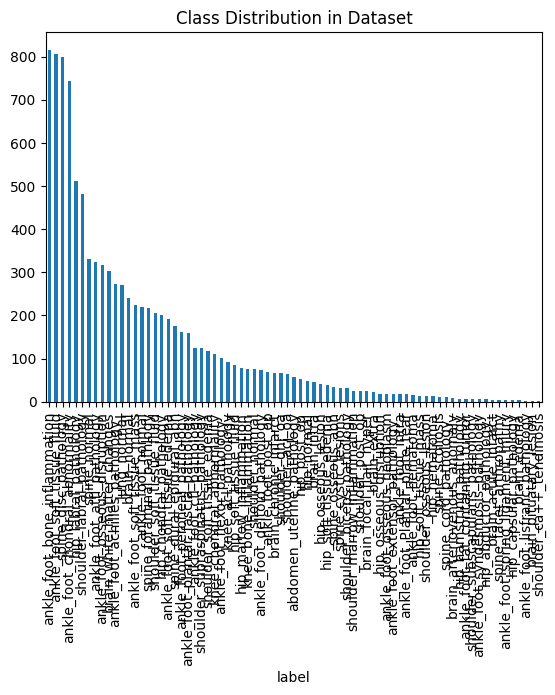

In [3]:
import pandas as pd

test_df = pd.read_csv("data/labels.csv")
label_counts = test_df['label'].value_counts()
label_counts.plot(kind='bar', title='Class Distribution in Dataset')

In [4]:
label_counts.tail(15)

label
spine_cord_pathology_                11
brain_arteriovenous_anomaly           9
hip_hamstring_pathology               7
ankle_foot_fat_containing_tumor       7
shoulder_subscapularis_pathology      6
ankle_foot_syndesmosis_pathology      6
hip_abductor_pathology_               6
brain_acute_infarct                   5
spine_facet_arthropathy               5
ankle_foot_spring_ligament_injury     3
hip_capsular_pathology                3
brain_edema                           3
ankle_foot_lisfranc_pathology         2
brain_pituatary_lesion                1
shoulder_ca++_tendinosis              1
Name: count, dtype: int64

In [5]:
large_classes = label_counts[label_counts > 10].index
print(len(large_classes))
print(large_classes)

61
Index(['ankle_foot_bone_inflammation', 'ankle_foot_soft_tissue_fluid',
       'spine_disc_pathology', 'ankle_foot_chondral_abnormality',
       'hip_labral_pathology', 'shoulder_labral_pathology', 'spine_normal',
       'ankle_foot_atfl_pathology', 'ankle_foot_osseous_disruption',
       'brain_white_matter_changes', 'ankle_foot_achilles_pathology_',
       'lung_normal', 'brain_normal', 'ankle_foot_soft_tissue_mass',
       'ankle_foot_normal', 'spine_foraminal_pathlogy',
       'shoulder_soft_tissue_fluid', 'hip_chondral_pathology',
       'ankle_foot_soft_tissue_edema', 'spine_dural_epidural_abn',
       'ankle_foot_peroneal_pathology', 'ankle_foot_plantar_fascia_pathology',
       'ankle_foot_cfl_pathology', 'shoulder_supraspinatus_pathology',
       'shoulder_soft_tissue_edema', 'knee_chondral_abnormality',
       'ankle_foot_flexor_pathology_', 'knee_acl_pathology',
       'hip_soft_tissue_fluid', 'hip_marrow_inflammation',
       'knee_bone_inflammation', 'shoulder_normal',
 

In [6]:
drop_classes_df = test_df[test_df['label'].isin(large_classes)]

drop_classes_df['label'].value_counts()

label
ankle_foot_bone_inflammation       816
ankle_foot_soft_tissue_fluid       806
spine_disc_pathology               798
ankle_foot_chondral_abnormality    743
hip_labral_pathology               511
                                  ... 
hip_soft_tissue_mass                14
shoulder_osseous_lesion             14
hip_hematoma                        13
spine_scoliosis                     12
spine_cord_pathology_               11
Name: count, Length: 61, dtype: int64

In [7]:
num_classes = drop_classes_df.label.value_counts().shape[0]

print(f"total number of classes in dataset: {num_classes}")
print(f"total datapoints in dataset: {len(drop_classes_df)}")

total number of classes in dataset: 61
total datapoints in dataset: 9936


This next cell will overwrite `data/labels.csv` with the new df that has the small classes removed

In [8]:
drop_classes_df.to_csv("data/labels.csv", index=False)

In [9]:
# check df saved correctly
df = pd.read_csv('data/labels.csv')

df.head()

,filename,pathology,modality,location,label
0,test_0.png,soft_tissue_fluid,mri,ankle foot,ankle_foot_soft_tissue_fluid
1,test_1.png,osseous_disruption,mri,ankle foot,ankle_foot_osseous_disruption
2,test_2.png,chondral_abnormality,mri,ankle foot,ankle_foot_chondral_abnormality
3,test_3.png,achilles_pathology_,mri,ankle foot,ankle_foot_achilles_pathology_
4,test_4.png,achilles_pathology_,mri,ankle foot,ankle_foot_achilles_pathology_
